## **Q3 - Feature Engineering and Regression Pipeline**

Building a reproducible scikit-learn regression pipeline to predict item-sold at a retail store

# **Task 1 - Data Feature Engineering**

In [11]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving q3_retail_promotions.csv to q3_retail_promotions.csv


In [12]:
df = pd.read_csv('q3_retail_promotions.csv')

print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: 1200 rows x 9 columns

Data Types:
transaction_date       object
store_id                int64
store_size             object
location_type          object
promotion_type         object
is_weekend              int64
is_festival             int64
competition_density     int64
items_sold              int64
dtype: object

Missing Values:
transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64

First 5 rows:


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [13]:
df['transaction_date'] = pd.to_datetime(df['transaction_date']) #convert date from string to proper datetime format
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek # 0=Monday, 6=Sunday
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print(f"Date range: {df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}")
print(f"\nNew columns created: year, month, day_of_week, is_month_end")
print(f"\nSample of new date features:")
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10)


Date range: 2022-01-01 to 2024-12-31

New columns created: year, month, day_of_week, is_month_end

Sample of new date features:


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0
8,2022-01-05,2022,1,2,0
9,2022-01-05,2022,1,2,0


## **Task 2 - Temporal Train-Test Split**

In [14]:
df = df.sort_values('transaction_date').reset_index(drop=True) #sort by date - oldest first

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx] # first 80% - older records
test_df = df.iloc[split_idx:] # last 20% - newer records

print(f"Total records: {len(df)}")
print(f"Split index: {split_idx}")
print(f"\nTrain set records: {len(train_df)} records")
print(f"Date Range: {train_df['transaction_date'].min().date()} to {train_df['transaction_date'].max().date()}")
print(f"\nTest set records: {len(test_df)} records")
print(f"Date Range: {test_df['transaction_date'].min().date()} to {test_df['transaction_date'].max().date()}")

Total records: 1200
Split index: 960

Train set records: 960 records
Date Range: 2022-01-01 to 2024-06-11

Test set records: 240 records
Date Range: 2024-06-12 to 2024-12-31


## **Task 3 - Preprocessing Pipeline**

In [16]:
drop_cols = ['transaction_date', 'store_id', 'items_sold']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['items_sold']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['items_sold']

#Defining categorical and Numerical columns
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [c for c in X_train.columns if c not in cat_cols]

print(f"Features used: {X_train.shape[1]} total")
print(f"\nNumerical columns ({len(num_cols)}): {num_cols}")
print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")
print(f"\nTarget: items_sold")
print(f"\nTraining features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Features used: 10 total

Numerical columns (7): ['is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

Categorical columns (3): ['promotion_type', 'location_type', 'store_size']

Target: items_sold

Training features shape: (960, 10)
Test features shape: (240, 10)


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop = 'first', sparse_output = False), cat_cols),
        ('scaler', StandardScaler(), num_cols)
    ])
print("ColumnTransformer built successfully.")
print(f"\nIt will:")
print(f"  -  One-Hot Encode: {cat_cols}")
print(f"  -  StandardScale: {num_cols}")

ColumnTransformer built successfully.

It will:
  -  One-Hot Encode: ['promotion_type', 'location_type', 'store_size']
  -  StandardScale: ['is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


## **Task 4 - Model Training and Evaluation**

In [25]:
# Linear Regression Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

lr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

 #fit only on training data
lr_pipe.fit(X_train, y_train)

#predict on test data
y_pred_lr = lr_pipe.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr)) #calculate metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression Results:")
print(f" RMSE: {rmse_lr:.4f}")
print(f" MAE: {mae_lr:.4f}")

Linear Regression Results:
 RMSE: 27.1252
 MAE: 21.0715


In [27]:
# Random Forest Regressor Pipeline
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

 #fit only on training data
rf_pipe.fit(X_train, y_train)

#predict on test data
y_pred_rf = rf_pipe.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf)) #calculate metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest Regressor Results:")
print(f" RMSE: {rmse_rf:.4f}")
print(f" MAE: {mae_rf:.4f}")

Random Forest Regressor Results:
 RMSE: 31.8976
 MAE: 25.5956


In [29]:
# Comparison table
comparison = pd.DataFrame({
    'Linear Regression': {'RMSE': rmse_lr, 'MAE': mae_lr},
    'Random Forest Regressor': {'RMSE': rmse_rf, 'MAE': mae_rf}
}).T

print(f"Model Comparison")
print(comparison.round(4).to_string())

Model Comparison
                            RMSE      MAE
Linear Regression        27.1252  21.0715
Random Forest Regressor  31.8976  25.5956


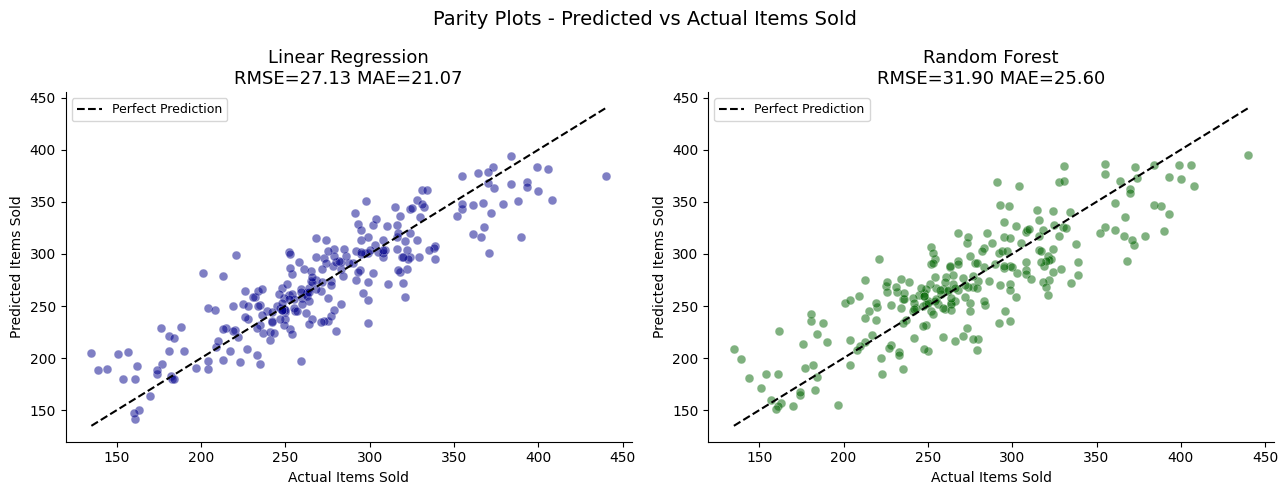

In [33]:
#Predicted(y-axis) vs Actual Plots(x-axis)

import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_info = [
    ('Linear Regression', y_pred_lr, rmse_lr, mae_lr, axes[0], 'darkblue'),
    ('Random Forest', y_pred_rf, rmse_rf, mae_rf, axes[1], 'darkgreen')
]

for name, y_pred, rmse, mae, ax, color in models_info:
  ax.scatter(y_test, y_pred, color=color, alpha = 0.5, s=40, edgecolors='white', linewidths=0.3)

  min_val = min(min(y_test), min(y_pred))
  max_val = max(max(y_test), max(y_pred))
  ax.plot([min_val, max_val], [min_val, max_val],
          color='black', linestyle='--', linewidth=1.5, label='Perfect Prediction')

  ax.set_title(f'{name}\nRMSE={rmse:.2f} MAE={mae:.2f}', fontsize = 13)
  ax.set_xlabel('Actual Items Sold')
  ax.set_ylabel('Predicted Items Sold')
  ax.legend(fontsize=9)
  ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Parity Plots - Predicted vs Actual Items Sold', fontsize=14)
plt.tight_layout()
plt.show()

# **Model Evaluation — Summary**

**Linear Regression performs better than Random Forest.**

It has lower error: RMSE (27.13 vs 31.90) and MAE (21.07 vs 25.60)

This indicates the relationship is mostly linear.

Random Forest likely overfits due to its complexity.

**Interpretation:** Predictions are off by ~27 items on average, which is reasonable given the data range.

In [35]:
#Feature Importances from Random Forest

ohe_feature_names = (rf_pipe.named_steps['preprocessor']
                     .named_transformers_['ohe']
                     .get_feature_names_out(cat_cols))

feature_names = np.concatenate([ohe_feature_names, num_cols])

importances = rf_pipe.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(f"Feature Importances from Random Forest:")
print(feat_imp.round(4).to_string())
print(f"\nTop 5 Most Influential Features:")
print(feat_imp.head(5).to_string())

Feature Importances from Random Forest:
store_size_small                 0.1844
is_festival                      0.1746
location_type_urban              0.1411
day_of_week                      0.0958
competition_density              0.0674
is_weekend                       0.0661
store_size_medium                0.0588
month                            0.0561
location_type_semi-urban         0.0405
promotion_type_loyalty_points    0.0352
year                             0.0231
promotion_type_category_offer    0.0204
promotion_type_free_gift         0.0155
promotion_type_flat_discount     0.0132
is_month_end                     0.0079

Top 5 Most Influential Features:
store_size_small       0.184408
is_festival            0.174562
location_type_urban    0.141088
day_of_week            0.095815
competition_density    0.067392


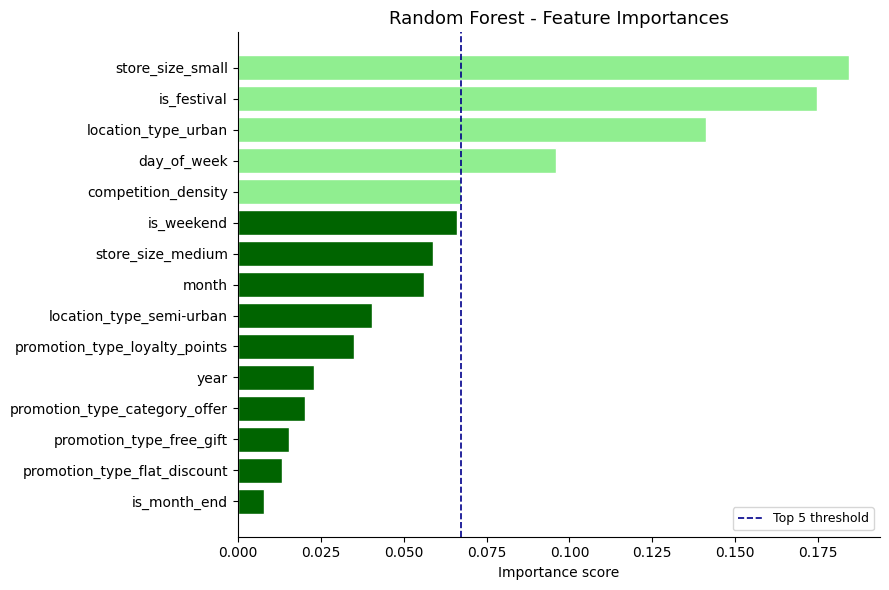

In [39]:
#Bar Chart

fig, ax = plt.subplots(figsize=(9,6))

colors_imp = ['lightgreen' if i < 5 else 'darkgreen' for i in range(len(feat_imp))]

ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors_imp[::-1], edgecolor='white')

ax.set_title('Random Forest - Feature Importances', fontsize=13)
ax.set_xlabel('Importance score')
ax.axvline(feat_imp.head(5).min(), color='darkblue', linestyle='--', linewidth=1.2, label='Top 5 threshold')

ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# **Top Influential Features — Summary**
**Key drivers of sales (Random Forest):**


store_size_small — biggest impact; small stores sell fewer items


is_festival — major sales boost during festivals


location_type_urban — urban stores perform better


day_of_week — sales vary by day


competition_density — more competitors reduce sales



**Insights:**


Store size and location are the strongest factors


Festivals significantly increase demand


Timing (day-wise) affects sales patterns


Competition lowers performance


Promotions have relatively low impact compared to other factors